# Applications of PostGIS Functions
In this notebook, we will look at OSM and GADM data and perform PostGIS function to perform basic exploratory analysis

In [1]:
import psycopg2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
directory = "T6-gsa/Session_5-6/"

We first establish a connection to our database

In [3]:
conn = psycopg2.connect(dbname="postgis", 
                 user="gsa2022", 
                 password="g5!V%T1Vmd", 
                 host="192.168.212.99", 
                 port=32771)

In [4]:
# Check the available schema in our database:
pd.read_sql('''
            SELECT nspname
            FROM pg_catalog.pg_namespace
            ''', conn).values

array([['pg_toast'],
       ['pg_temp_1'],
       ['pg_toast_temp_1'],
       ['pg_catalog'],
       ['br_20000801'],
       ['information_schema'],
       ['topology'],
       ['br_20100801'],
       ['public'],
       ['gadm'],
       ['ph_20200501'],
       ['pg_temp_7'],
       ['pg_toast_temp_7'],
       ['pg_temp_8'],
       ['govt'],
       ['namria_hazard'],
       ['pg_toast_temp_8'],
       ['pg_temp_15'],
       ['pedestrians'],
       ['pg_temp_4'],
       ['pg_toast_temp_15'],
       ['pg_toast_temp_4'],
       ['ph_20150801'],
       ['pg_temp_21'],
       ['deped'],
       ['pg_toast_temp_21'],
       ['au_20110809'],
       ['dpwh'],
       ['pg_temp_14'],
       ['au_20160809'],
       ['pg_toast_temp_14'],
       ['pg_temp_45'],
       ['pg_toast_temp_45'],
       ['gadm_v4_1'],
       ['au_20210810'],
       ['bgd_20010127'],
       ['bgd_20110319'],
       ['bgd_20220621'],
       ['br_20220731'],
       ['in_20000630'],
       ['in_20100630'],
       ['in_20200930'

We will be using two schemas:
1. Public : contains OSM data
2. GADM : contains GADM data

In [5]:
#Check the contents of the public schema
pd.read_sql('''
            SELECT *
            FROM information_schema.tables
            WHERE table_schema = 'public'
            ''', conn)

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action
0,postgis,public,spatial_ref_sys,BASE TABLE,None,None,None,None,None,YES,NO,None
1,postgis,public,ph_line,BASE TABLE,None,None,None,None,None,YES,NO,None
2,postgis,public,pop_census_place,BASE TABLE,None,None,None,None,None,YES,NO,None
3,postgis,public,geography_columns,VIEW,None,None,None,None,None,NO,NO,None
4,postgis,public,ph_roads,BASE TABLE,None,None,None,None,None,YES,NO,None
5,postgis,public,au_point,BASE TABLE,None,None,None,None,None,YES,NO,None
6,postgis,public,geometry_columns,VIEW,None,None,None,None,None,YES,NO,None
7,postgis,public,ph_polygon,BASE TABLE,None,None,None,None,None,YES,NO,None
8,postgis,public,ph_point,BASE TABLE,None,None,None,None,None,YES,NO,None
9,postgis,public,au_roads,BASE TABLE,None,None,None,None,None,YES,NO,None


In [6]:
#Check the contents of the GADM schema
pd.read_sql('''
            SELECT *
            FROM information_schema.tables
            WHERE table_schema = 'gadm'
            ''', conn)

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action
0,postgis,gadm,adm0,BASE TABLE,None,None,None,None,None,YES,NO,None
1,postgis,gadm,adm1,BASE TABLE,None,None,None,None,None,YES,NO,None
2,postgis,gadm,adm4,BASE TABLE,None,None,None,None,None,YES,NO,None
3,postgis,gadm,adm3,BASE TABLE,None,None,None,None,None,YES,NO,None
4,postgis,gadm,adm5,BASE TABLE,None,None,None,None,None,YES,NO,None
5,postgis,gadm,ph_brgy,BASE TABLE,None,None,None,None,None,YES,NO,None
6,postgis,gadm,ph_hum,BASE TABLE,None,None,None,None,None,YES,NO,None
7,postgis,gadm,adm2,BASE TABLE,None,None,None,None,None,YES,NO,None
8,postgis,gadm,ph,BASE TABLE,None,None,None,None,None,YES,NO,None
9,postgis,gadm,au,BASE TABLE,None,None,None,None,None,YES,NO,None


## 1. Reading OSM Points

In [ ]:
pd.set_option('display.max_columns', 200)

In [8]:
#Check the contents of ph_points
df = pd.read_sql('''
                 SELECT *
                 FROM public.ph_point
                 LIMIT 20
                 ''', conn)
df

,osm_id,access,addr:housename,addr:housenumber,addr:interpolation,admin_level,aerialway,aeroway,amenity,area,barrier,bicycle,brand,bridge,boundary,building,capital,construction,covered,culvert,cutting,denomination,disused,ele,embankment,foot,generator:source,harbour,highway,historic,horse,intermittent,junction,landuse,layer,leisure,lock,man_made,military,motorcar,name,natural,office,oneway,operator,place,population,power,power_source,public_transport,railway,ref,religion,route,service,shop,sport,surface,toll,tourism,tower:type,tunnel,water,waterway,wetland,width,wood,z_order,way
0,4332833465,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,slipway,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E6100000EBA7FFAC790C5C4030963325A3B0...
1,5127953795,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Đá Tây,None,None,None,None,village,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E610000087527B116D105C4055FC3ACB87BB...
2,4332833991,None,None,None,None,None,None,None,ferry_terminal,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E610000022CC481861105C40F863A428E1BB...
3,2645876983,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,lighthouse,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E61000007E1EA33C73105C40505A136635BC...
4,2645876976,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,West Reef,None,None,None,None,island,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E6100000060BCCAF8B105C40EFE192E34EBD...
5,4332856711,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,slipway,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E6100000A206787789165C402614C7269EDC...
6,2645876984,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Central Reef,None,None,None,None,island,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E610000078D2C26595165C40B222B42FEADC...
7,2074532777,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,中礁,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0101000020E610000010429B7777175C401789BFDCDDDD...
8,3649052507,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,

#### Class Exercise
- What are the top 10 amenity types in the ph_point table?
- What are the top 10 most frequent "brand" in the table?

In [9]:
# Top 10 amenity types
pd.read_sql('''
            SELECT ph_point.amenity, count(*) as "Counts of Amenity"
            FROM public.ph_point
            WHERE ph_point.amenity IS NOT NULL
            GROUP BY ph_point.amenity
            ORDER BY "Counts of Amenity" DESC
            LIMIT 10
            ''', conn)

,amenity,Counts of Amenity
0,restaurant,8869
1,school,5853
2,bank,5369
3,fast_food,5249
4,place_of_worship,4652
5,fuel,3799
6,pharmacy,2956
7,cafe,2171
8,parking,1661
9,bar,1177


In [10]:
# Top 10 brands
pd.read_sql('''
            SELECT ph_point.brand, count(*) as "Counts of Brands"
            FROM public.ph_point
            WHERE ph_point.brand IS NOT NULL
            GROUP BY 1
            ORDER BY 2 DESC
            LIMIT 10
            ''', conn)

,brand,Counts of Brands
0,Petron,607
1,Shell,341
2,Caltex,267
3,Western Union,175
4,Flying V,93
5,SeaOil,92
6,Total,82
7,Phoenix,73
8,Jetti,20
9,Gas Station,18


In [11]:
# Top 10 names
pd.read_sql('''
            SELECT ph_point.name, count(*) as "Names"
            FROM public.ph_point
            WHERE ph_point.name IS NOT NULL
            GROUP BY 1
            ORDER BY 2 DESC
            LIMIT 10
            ''', conn)


,name,Names
0,Landslide,2621
1,7-Eleven,1234
2,Petron,750
3,Jollibee,619
4,Mercury Drug,547
5,BDO,520
6,BPI,410
7,Shell,389
8,Caltex,318
9,Chowking,302


#### Exercise (Choose at least 1 to answer)
- Find out which "bars" violate the rule that they cannot be within 500 units from a "school"
- What restaurant is the most accessible to banks in terms of distance?
- On average, how far should I need to walk from an atm machine to the nearest toilet?

In [12]:
pd.read_sql('''
            SELECT ST_SRID(p.way)
            FROM public.ph_point p
            LIMIT 10
            ''', conn)

,st_srid
0,4326
1,4326
2,4326
3,4326
4,4326
5,4326
6,4326
7,4326
8,4326
9,4326


In [13]:
df_1 = pd.read_sql('''
                 SELECT p1.name, p2.name, st_distance(st_transform(p1.way, 3123), st_transform(p2.way, 3123)), ST_X(p1.way), ST_Y(p1.way)
                 FROM public.ph_point as p1
                 JOIN public.ph_point as p2 ON st_dwithin(st_transform(p1.way, 3123), st_transform(p2.way, 3123), 500)
                 WHERE p1.amenity = 'bar' AND p2.amenity = 'school'
                 ORDER BY 3 DESC
                 LIMIT 10
                 ''', conn)

df_1

,name,name,st_distance,st_x,st_y
0,Bersabaren Bar and Resort,Zeferino Arroyo High School,499.592115,123.402388,13.446706
1,Uno,Lincolnshire Intermediate School,499.396161,121.054833,14.578843
2,Senor Paquito bar,COJ Catholic Progressive School,498.736968,121.039880,14.635803
3,4j's Roses Vidoke Bar,Calapandayan Elementary School,498.049756,120.235277,14.869725
4,Ringside,NATIONAL MARITIME POLYTECHNIC Makati (NMP),497.863788,121.030762,14.563750
5,Bersabaren Bar and Resort,San Isidro Elementary School,497.780022,123.402388,13.446706
6,Jefz Cafe,STIt,497.674010,120.990500,14.573752
7,jers KARAOKE lounge,None,497.191616,120.984631,14.571884
8,Metro Concert Bar,Paltok Elementary School,497.172360,121.026965,14.643290
9,Doy's Seafood & Grill,None,497.113341,123.857404,9.646085


In [14]:
df_2 = pd.read_sql('''
    SELECT p1.name as restaurant, 
           COUNT(p2.name) as nearby_banks,
           MIN(st_distance(st_transform(p1.way, 3123), st_transform(p2.way, 3123))) as closest_bank_distance
    FROM public.ph_point as p1
    JOIN public.ph_point as p2 ON st_dwithin(st_transform(p1.way, 3123), st_transform(p2.way, 3123), 500)
    WHERE p1.amenity = 'restaurant' AND p2.amenity = 'bank'
    GROUP BY p1.name, p1.way
    ORDER BY nearby_banks DESC, closest_bank_distance ASC
    LIMIT 10
''', conn)

In [15]:
df_2

,restaurant,nearby_banks,closest_bank_distance
0,RAMEN NAGI ラーメン凪,127,42.294451
1,Shakey's,125,49.140933
2,Mang Inasal,124,44.143085
3,Davao Tuna Grill,124,62.617108
4,Tower Club,123,16.442832
5,Shakey's,123,56.899994
6,Tan Tan Men House,122,61.466628
7,Chilli Pepper,122,73.475567
8,Sisig Society,122,83.478633
9,XO 46 Bistro Filipino,121,20.282028


In [16]:
df_3 = pd.read_sql('''
    SELECT AVG(min_distance) as avg_walk_to_nearest_toilet
    FROM (
        SELECT p1.name,
               MIN(st_distance(st_transform(p1.way, 3123), st_transform(p2.way, 3123))) as min_distance
        FROM public.ph_point as p1
        JOIN public.ph_point as p2 ON st_dwithin(st_transform(p1.way, 3123), st_transform(p2.way, 3123), 500)
        WHERE p1.amenity = 'atm' AND p2.amenity = 'toilets'
        GROUP BY p1.name, p1.way
    ) as nearest_toilets
''', conn)

df_3

,avg_walk_to_nearest_toilet
0,215.467068


## 2. Reading OSM Lines and Polygons

In [17]:
# Check the contents of ph_line and ph_polygon
df_line = pd.read_sql('''
                      SELECT p.name, count(*)
                      FROM ph_line as p
                      GROUP BY 1
                      ORDER BY 2 DESC
                      LIMIT 10
                      ''', conn)

df_line

,name,count
0,None,526968
1,Maharlika Highway,1182
2,Emilio Aguinaldo Highway,352
3,Surigao - Davao Coastal Road,304
4,National Highway,292
5,TPLEX,282
6,MacArthur Highway,275
7,Governor's Drive,261
8,Bridge,242
9,Sampaguita,230


In [18]:
df_polygon = pd.read_sql('''
SELECT p.name, count(*)
FROM ph_polygon as p
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
''',conn)
df_polygon

,name,count
0,None,4824952
1,Landslide,631
2,Petron,588
3,Shell,425
4,Caltex,330
5,2,259
6,Iglesia ni Cristo,257
7,Cemetery,255
8,1,252
9,house,249


## 3. Reading GADM data

In [19]:
# Check the contents of gadm.ph
df_gadm = pd.read_sql('''
SELECT *
FROM gadm.ph
LIMIT 10
''',conn)
df_gadm

,gid,gid_0,name_0,gid_1,name_1,nl_name_1,gid_2,name_2,varname_2,nl_name_2,type_2,engtype_2,cc_2,hasc_2,geom
0,1,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.1_1,Bangued,None,None,Bayan|Munisipyo,Municipality,140101,PH.AB.BN,0106000020E610000001000000010300000001000000C7...
1,2,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.2_1,Boliney,None,None,Bayan|Munisipyo,Municipality,140102,PH.AB.BL,0106000020E6100000010000000103000000010000001F...
2,3,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.3_1,Bucay,None,None,Bayan|Munisipyo,Municipality,140103,PH.AB.BU,0106000020E61000000100000001030000000100000072...
3,4,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.4_1,Bucloc,None,None,Bayan|Munisipyo,Municipality,140104,PH.AB.BC,0106000020E6100000010000000103000000010000000F...
4,5,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.5_1,Daguioman,None,None,Bayan|Munisipyo,Municipality,140105,PH.AB.DG,0106000020E6100000010000000103000000010000001C...
5,15,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.15_1,Malibcong,None,None,Bayan|Munisipyo,Municipality,140115,PH.AB.ML,0106000020E61000000100000001030000000100000026...
6,1514,PHL,Philippines,PHL.75_1,Surigao del Sur,None,PHL.75.1_1,Barobo,None,None,Bayan|Munisipyo,Municipality,166801,PH.SS.BR,0106000020E61000000300000001030000000100000014...
7,6,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.6_1,Danglas,None,None,Bayan|Munisipyo,Municipality,140106,PH.AB.DN,0106000020E61000000100000001030000000100000070...
8,7,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.7_1,Dolores,None,None,Bayan|Munisipyo,Municipality,140107,PH.AB.DL,0106000020E61000000100000001030000000100000090...
9,8,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.8_1,La Paz,None,None,Bayan|Munisipyo,Municipality,140108,PH.AB.LP,0106000020E610000001000000010300000001000000A1...


In [20]:
# What's the difference of name_0, name_1, and name_2?


In [21]:
df_gadm = pd.read_sql('''
SELECT *
FROM gadm.ph
LIMIT 10
''',conn)
df_gadm

,gid,gid_0,name_0,gid_1,name_1,nl_name_1,gid_2,name_2,varname_2,nl_name_2,type_2,engtype_2,cc_2,hasc_2,geom
0,1,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.1_1,Bangued,None,None,Bayan|Munisipyo,Municipality,140101,PH.AB.BN,0106000020E610000001000000010300000001000000C7...
1,2,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.2_1,Boliney,None,None,Bayan|Munisipyo,Municipality,140102,PH.AB.BL,0106000020E6100000010000000103000000010000001F...
2,3,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.3_1,Bucay,None,None,Bayan|Munisipyo,Municipality,140103,PH.AB.BU,0106000020E61000000100000001030000000100000072...
3,4,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.4_1,Bucloc,None,None,Bayan|Munisipyo,Municipality,140104,PH.AB.BC,0106000020E6100000010000000103000000010000000F...
4,5,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.5_1,Daguioman,None,None,Bayan|Munisipyo,Municipality,140105,PH.AB.DG,0106000020E6100000010000000103000000010000001C...
5,15,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.15_1,Malibcong,None,None,Bayan|Munisipyo,Municipality,140115,PH.AB.ML,0106000020E61000000100000001030000000100000026...
6,1514,PHL,Philippines,PHL.75_1,Surigao del Sur,None,PHL.75.1_1,Barobo,None,None,Bayan|Munisipyo,Municipality,166801,PH.SS.BR,0106000020E61000000300000001030000000100000014...
7,6,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.6_1,Danglas,None,None,Bayan|Munisipyo,Municipality,140106,PH.AB.DN,0106000020E61000000100000001030000000100000070...
8,7,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.7_1,Dolores,None,None,Bayan|Munisipyo,Municipality,140107,PH.AB.DL,0106000020E61000000100000001030000000100000090...
9,8,PHL,Philippines,PHL.1_1,Abra,None,PHL.1.8_1,La Paz,None,None,Bayan|Munisipyo,Municipality,140108,PH.AB.LP,0106000020E610000001000000010300000001000000A1...


#### Exercise:
- What is the top 10 most common city/municipality name?
- Which province has the most city/municipality? The least?

In [22]:
pd.read_sql('''
SELECT name_2, count(*)
FROM gadm.ph
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
''',conn)

,name_2,count
0,San Isidro,9
1,San Jose,9
2,Santa Maria,7
3,Rizal,7
4,San Juan,7
5,San Miguel,7
6,Pilar,7
7,Santa Cruz,6
8,Quezon,6
9,Carmen,6


In [23]:
pd.read_sql('''
SELECT name_1, count(*)
FROM gadm.ph
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
''',conn)

,name_1,count
0,Cebu,54
1,Bohol,48
2,Pangasinan,48
3,Iloilo,44
4,Leyte,43
5,Lanao del Sur,42
6,Quezon,42
7,Camarines Sur,39
8,Isabela,37
9,Maguindanao,35


In [24]:
pd.read_sql('''
SELECT name_1, count(*)
FROM gadm.ph
GROUP BY 1
ORDER BY 2 ASC
LIMIT 10
''',conn)

,name_1,count
0,Camiguin,5
1,Guimaras,5
2,Quirino,6
3,Batanes,6
4,Siquijor,6
5,Marinduque,6
6,Apayao,7
7,Sarangani,7
8,Dinagat Islands,7
9,Biliran,8


## 4. Spatial Analysis using GADM

In [25]:
# What is the total area and perimeter of Makati City?
pd.read_sql('''
SELECT *, 
        st_area(st_transform(g.geom,3123)) as area, 
        st_perimeter(st_transform(g.geom,3123)) as perimeter 
FROM gadm.ph g
WHERE name_2 LIKE '%Makati%'
''',conn)

,gid,gid_0,name_0,gid_1,name_1,nl_name_1,gid_2,name_2,varname_2,nl_name_2,type_2,engtype_2,cc_2,hasc_2,geom,area,perimeter
0,963,PHL,Philippines,PHL.47_1,Metropolitan Manila,None,PHL.47.3_1,Makati City,"Makati, City of",None,Lungsod|Siyudad,City,137602,PH.MM.MK,0106000020E6100000010000000103000000010000009B...,3.174949e+07,27681.695213


In [26]:
# What is the largest city/municipality in terms of area? perimeter?
pd.read_sql('''
SELECT name_2, st_area(st_transform(g.geom,3123))
FROM gadm.ph g
ORDER BY 2 DESC
''',conn)

,name_2,st_area
0,Sablayan,2.349507e+09
1,Davao City,2.235635e+09
2,Puerto Princesa City,2.179525e+09
3,Nagtipunan,1.523349e+09
4,Zamboanga City,1.462348e+09
...,...,...
1642,Pateros,1.954985e+06
1643,Sampaloc Lake,8.772879e+05
1644,Kalibato Lake,5.400293e+05
1645,Waterbody,5.239115e+05


In [27]:
pd.read_sql('''
SELECT name_2, st_perimeter(st_transform(g.geom,3123))
FROM gadm.ph g
ORDER BY 2 DESC
''',conn)

,name_2,st_perimeter
0,Taytay,896027.164587
1,Coron,588731.661532
2,Puerto Princesa City,509509.370551
3,Culion,479856.924442
4,Zamboanga City,424608.281021
...,...,...
1642,Pateros,7392.438703
1643,Waterbody,3992.607178
1644,Sampaloc Lake,3537.255489
1645,Kalibato Lake,2957.150366


In [28]:
import geopandas as gpd

In [29]:
df_taytay = gpd.read_postgis('''
SELECT *
FROM gadm.ph g
WHERE name_2 = 'Taytay'
''',conn)

<Axes: >

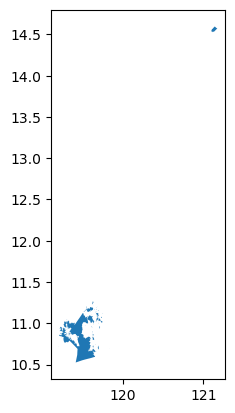

In [30]:
df_taytay.plot()

#### Exercise (Choose at least 1 to answer)
- How far is Makati City from Quezon City?
- What cities are directly connected to Makati city?
- At which city is the geographic center of Metro Manila located?
- How long is the shared perimeter of Taguig and Makati?


In [31]:
pd.read_sql('''
SELECT ST_Distance(ST_Transform(g1.geom,3123),ST_Transform(g2.geom,3123))
FROM gadm.ph g1, gadm.ph g2
WHERE g1.name_2 LIKE '%Makati%'
AND g2.name_2 LIKE '%Quezon City%'
''',conn)

,st_distance
0,2352.966439


In [32]:
pd.read_sql('''
SELECT g2.name_2
FROM gadm.ph g1, gadm.ph g2
WHERE g1.name_2 LIKE '%Makati%'
AND ST_Touches(g1.geom,g2.geom)
''',conn)

,name_2
0,Pateros
1,Mandaluyong
2,Manila
3,Pasay City
4,Pasig City
5,Taguig


In [33]:
pd.read_sql('''
SELECT st_length(st_intersection(st_transform(g1.geom,3123),st_transform(g2.geom,3123)))
FROM gadm.ph g1, gadm.ph g2
WHERE g1.name_2 = 'Makati City' AND g2.name_2 = 'Taguig'
''',conn)

,st_length
0,8778.193956


In [34]:
gdf_gadm1 = gpd.read_postgis(
'''
SELECT 
    ST_Centroid(ST_Union(geom)) as geographic_center
FROM 
    gadm.ph
WHERE 
    name_1 like '%Manila%'
''', conn, geom_col='geographic_center'
)

In [35]:
gdf_gadm1

,geographic_center
0,POINT (121.03257 14.59874)


<Axes: >

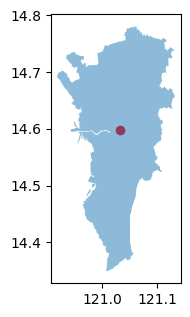

In [36]:
gdf_gadm1 = gpd.read_postgis(
'''
SELECT 
    ST_Centroid(ST_Union(geom)) as geographic_center
FROM 
    gadm.ph
WHERE 
    name_1 like '%Manila%'
''', conn, geom_col='geographic_center'
)

gdf_gadm2 = gpd.read_postgis(
'''
SELECT 
    ST_Union(geom) as g
FROM 
    gadm.ph
WHERE 
    name_1 like '%Manila%'
''', conn, geom_col='g'
)

fig, ax1 = plt.subplots(figsize=(5, 3.5))
gdf_gadm1.plot(ax=ax1, color='r')
gdf_gadm2.plot(ax=ax1, alpha=0.5)

## 5. Combining GADM and OSM info

In [37]:
# What are the most frequent amenities inside Makati City?
pd.read_sql('''
SELECT p.amenity, count(*)
FROM gadm.ph as g
JOIN public.ph_point p ON st_within(p.way,g.geom)
WHERE g.name_2 = 'Makati City' AND p.amenity IS NOT NULL
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
''', conn)

,amenity,count
0,restaurant,678
1,bank,462
2,fast_food,246
3,cafe,187
4,bar,99
5,pharmacy,63
6,parking,51
7,school,39
8,place_of_worship,39
9,atm,36
